# Emotion Detection in Tweets

**DS 423 — Machine Learning with Large Datasets**  
**Group 22 — NLP** | Duy Tan University, Da Nang

| Member | Student ID | Role |
|--------|------------|------|
| Lâm Nhật Huy | 29211465364 | Data & Analysis Lead |
| Nguyễn Thị Lam Giang | 29201458314 | Modeling & Evaluation Lead |

---

## Table of Contents

1. [Setup & Imports](#1-setup--imports)
2. [Introduction](#2-introduction)
3. [Dataset Loading](#3-dataset-loading)
4. [Exploratory Data Analysis (EDA)](#4-exploratory-data-analysis-eda)
5. [Text Preprocessing](#5-text-preprocessing)
6. [Feature Engineering](#6-feature-engineering)
7. [Baseline Model Comparison](#7-baseline-model-comparison)
8. [Model Training & Hyperparameter Tuning](#8-model-training--hyperparameter-tuning)
9. [Results & Evaluation](#9-results--evaluation)
10. [Conclusion & Future Work](#10-conclusion--future-work)

---
## 1. Setup & Imports

In [1]:
# Standard library
import os
import re
import warnings
from collections import Counter
from pathlib import Path

# Data & visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ML
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

# Download NLTK resources (safe to re-run)
for resource in ["stopwords", "wordnet", "omw-1.4"]:
    nltk.download(resource, quiet=True)

# Output directories
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environment ready.")

Environment ready.


---
## 2. Introduction

### Problem Statement

Brands, governments, and researchers increasingly monitor **public emotion** on social media to understand how people feel about products, events, or policies. Automatically detecting emotions such as **joy, anger, sadness, fear, love, and surprise** from short text posts enables real-time sentiment dashboards and early warning systems.

### Objective

Build a **multi-class text classifier** that:
- Loads and explores the [dair-ai/emotion](https://huggingface.co/datasets/dair-ai/emotion) dataset
- Preprocesses raw tweet text
- Trains a supervised ML model with hyperparameter tuning
- Evaluates performance using **Accuracy, Precision, Recall, F1-score**, and a **confusion matrix**

---
## 3. Dataset Loading

Source: [Emotion Dataset (dair-ai)](https://huggingface.co/datasets/dair-ai/emotion) on Hugging Face.

| Split | Purpose |
|-------|----------|
| `train` | Model training |
| `validation` | Hyperparameter tuning |
| `test` | Final evaluation |

In [2]:
# Label mapping from the dataset documentation
LABEL_NAMES = ["sadness", "joy", "love", "anger", "fear", "surprise"]

raw_ds = load_dataset("dair-ai/emotion")
print(raw_ds)

def to_dataframe(split):
    """Convert a HuggingFace split to a pandas DataFrame with string labels."""
    df = raw_ds[split].to_pandas()
    df["emotion"] = df["label"].map(lambda x: LABEL_NAMES[x])
    return df[["text", "label", "emotion"]]

train_df = to_dataframe("train")
val_df   = to_dataframe("validation")
test_df  = to_dataframe("test")

print(f"\nTrain: {len(train_df):,} | Validation: {len(val_df):,} | Test: {len(test_df):,}")
train_df.head()

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Train: 16,000 | Validation: 2,000 | Test: 2,000


,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


---
## 4. Exploratory Data Analysis (EDA)

We examine class distribution, tweet length, and sample texts before modeling.

In [3]:
# Basic statistics
train_df["char_len"] = train_df["text"].str.len()
train_df["word_count"] = train_df["text"].str.split().str.len()

display(train_df.describe())
print("\nMissing values:", train_df.isnull().sum().sum())
print("Duplicate texts:", train_df["text"].duplicated().sum())

,label,char_len,word_count
count,16000.000000,16000.000000,16000.000000
mean,1.565937,96.845812,19.166313
std,1.501430,55.904953,10.986905
min,0.000000,7.000000,2.000000
25%,0.000000,53.000000,11.000000
50%,1.000000,86.000000,17.000000
75%,3.000000,129.000000,25.000000
max,5.000000,300.000000,66.000000



Missing values: 0
Duplicate texts: 31


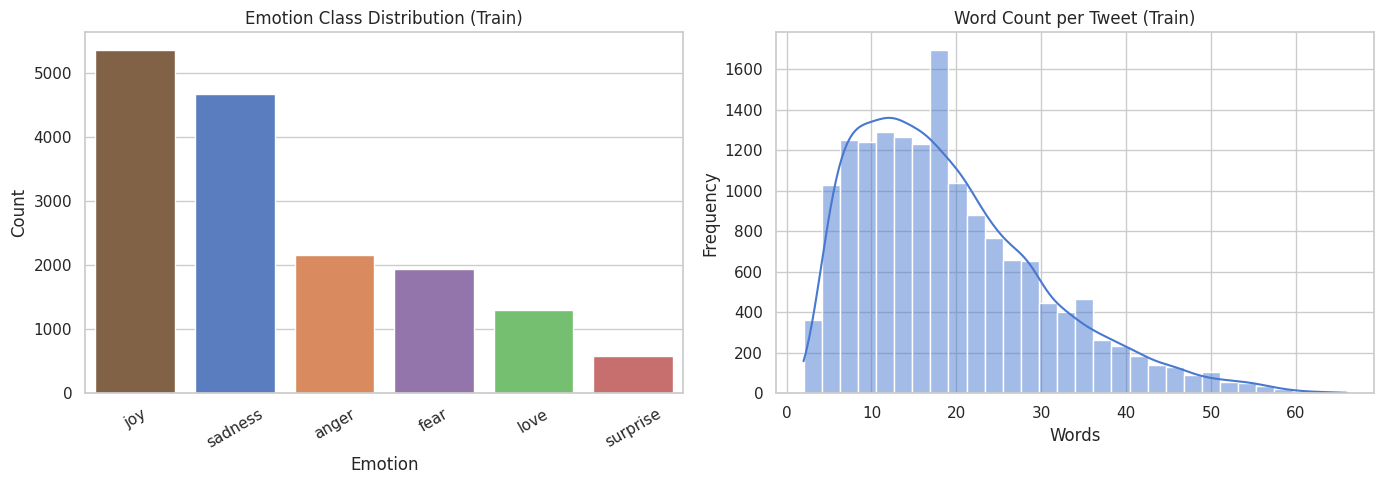

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
order = train_df["emotion"].value_counts().index
sns.countplot(data=train_df, x="emotion", order=order, ax=axes[0], hue="emotion", legend=False)
axes[0].set_title("Emotion Class Distribution (Train)")
axes[0].set_xlabel("Emotion")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

# Tweet length distribution
sns.histplot(train_df["word_count"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Word Count per Tweet (Train)")
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_overview.png", bbox_inches="tight")
plt.show()

In [5]:
# Sample tweets per emotion
samples = (
    train_df.groupby("emotion", group_keys=False)
    .apply(lambda g: g.sample(2, random_state=RANDOM_STATE))
    [["emotion", "text"]]
)
display(samples)

,emotion,text
15428,anger,i ve been feeling a bit cranky with the kids t...
4989,anger,i feel frustrated sometimes with my mac lipsti...
4996,fear,i can feel the frantic beat of his heart but c...
7684,fear,i feel a little suspicious
14642,joy,i feel im rather innocent in that respect
10462,joy,im feeling quite adventurous and tried out tho...
14343,love,i mean fuck i feel like i was way more conside...
6349,love,i remember a couple of years ago i was feeling...
11433,sadness,im feeling so lousy they tried to cheer me up ...
9343,sadness,i feel highly disadvantaged


---
## 5. Text Preprocessing

Steps applied to each tweet:
1. Lowercase
2. Remove URLs, mentions (`@user`), and hashtags (`#`)
3. Remove non-alphabetic characters
4. Tokenize, remove English stopwords
5. Lemmatize tokens

In [6]:
STOP_WORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

def clean_text(text: str) -> str:
    """Clean and normalize a single tweet."""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)          # URLs
    text = re.sub(r"@\w+", "", text)                     # mentions
    text = re.sub(r"#(\w+)", r"\1", text)                # hashtags → word
    text = re.sub(r"[^a-z\s]", " ", text)                 # keep letters only
    tokens = [LEMMATIZER.lemmatize(w) for w in text.split() if w not in STOP_WORDS and len(w) > 1]
    return " ".join(tokens)

# Apply preprocessing to all splits
for df in [train_df, val_df, test_df]:
    df["clean_text"] = df["text"].apply(clean_text)

print("Before vs After preprocessing (sample):")
for i in range(3):
    print(f"\n[Original]  {train_df.iloc[i]['text']}")
    print(f"[Cleaned]   {train_df.iloc[i]['clean_text']}")

Before vs After preprocessing (sample):

[Original]  i didnt feel humiliated
[Cleaned]   didnt feel humiliated

[Original]  i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
[Cleaned]   go feeling hopeless damned hopeful around someone care awake

[Original]  im grabbing a minute to post i feel greedy wrong
[Cleaned]   im grabbing minute post feel greedy wrong


---
## 6. Feature Engineering

We convert cleaned text into numerical features using **TF-IDF** (Term Frequency–Inverse Document Frequency), which captures how important a word is to a document relative to the corpus.

| Parameter | Value | Rationale |
|-----------|-------|------------|
| `max_features` | 10,000 | Limit vocabulary size for efficiency |
| `ngram_range` | (1, 2) | Capture unigrams and bigrams |
| `min_df` | 2 | Ignore very rare terms |

In [7]:
X_train = train_df["clean_text"]
y_train = train_df["label"]
X_val   = val_df["clean_text"]
y_val   = val_df["label"]
X_test  = test_df["clean_text"]
y_test  = test_df["label"]

vectorizer = TfidfVectorizer(
    max_features=10_000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"Vocabulary size: {len(vectorizer.vocabulary_):,}")

TF-IDF matrix shape (train): (16000, 10000)
Vocabulary size: 10,000


---
## 7. Baseline Model Comparison

Before tuning our final model, we compare several baselines on the **test set** using the same preprocessed text.
This shows how much the learned models improve over a trivial majority-class predictor.

In [8]:
def evaluate_model(name, model, x_train, y_train, x_test, y_test):
    """Fit a model and return test-set accuracy and weighted F1-score."""
    model.fit(x_train, y_train)
    preds = model.predict(x_test)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Weighted F1": f1_score(y_test, preds, average="weighted", zero_division=0),
    }


tfidf = TfidfVectorizer(
    max_features=10_000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)

majority_label = Counter(y_train).most_common(1)[0][0]
majority_name = f"Majority Class (always {LABEL_NAMES[majority_label]})"
majority_preds = [majority_label] * len(y_test)

baseline_rows = [
    {
        "Model": majority_name,
        "Accuracy": accuracy_score(y_test, majority_preds),
        "Weighted F1": f1_score(y_test, majority_preds, average="weighted", zero_division=0),
    },
    evaluate_model(
        "TF-IDF + Multinomial Naive Bayes",
        Pipeline([("tfidf", tfidf), ("clf", MultinomialNB())]),
        X_train,
        y_train,
        X_test,
        y_test,
    ),
    evaluate_model(
        "TF-IDF + Linear SVM",
        Pipeline([
            ("tfidf", tfidf),
            ("clf", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE)),
        ]),
        X_train,
        y_train,
        X_test,
        y_test,
    ),
]

baseline_df = pd.DataFrame(baseline_rows)

print("=== Baseline Comparison (Test Set) ===")
display(
    baseline_df.assign(
        Accuracy=baseline_df["Accuracy"].map(lambda x: f"{x:.4f}"),
        **{"Weighted F1": baseline_df["Weighted F1"].map(lambda x: f"{x:.4f}")},
    )
)

=== Baseline Comparison (Test Set) ===


,Model,Accuracy,Weighted F1
0,Majority Class (always joy),0.3475,0.1792
1,TF-IDF + Multinomial Naive Bayes,0.7700,0.7345
2,TF-IDF + Linear SVM,0.9005,0.9019


---
## 8. Model Training & Hyperparameter Tuning

**Selected model:** Logistic Regression — strong performance on high-dimensional sparse text features.

**Tuning:** `GridSearchCV` with 3-fold stratified cross-validation on the training set, evaluated by weighted F1-score.

In [9]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10_000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

param_grid = {
    "clf__C": [0.1, 1.0, 5.0],
    "clf__class_weight": [None, "balanced"],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV F1 (weighted): {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

# Add tuned Logistic Regression to the baseline comparison table
lr_metrics = evaluate_model(
    "TF-IDF + Logistic Regression (tuned)",
    best_model,
    X_train,
    y_train,
    X_test,
    y_test,
)
comparison_df = pd.concat(
    [baseline_df, pd.DataFrame([lr_metrics])], ignore_index=True
)
print("\n=== Full Model Comparison (Test Set) ===")
display(
    comparison_df.assign(
        Accuracy=comparison_df["Accuracy"].map(lambda x: f"{x:.4f}"),
        **{"Weighted F1": comparison_df["Weighted F1"].map(lambda x: f"{x:.4f}")},
    )
)
comparison_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)

Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best parameters: {'clf__C': 5.0, 'clf__class_weight': 'balanced'}
Best CV F1 (weighted): 0.9009

=== Full Model Comparison (Test Set) ===


,Model,Accuracy,Weighted F1
0,Majority Class (always joy),0.3475,0.1792
1,TF-IDF + Multinomial Naive Bayes,0.7700,0.7345
2,TF-IDF + Linear SVM,0.9005,0.9019
3,TF-IDF + Logistic Regression (tuned),0.9025,0.9043


In [10]:
# Validation set performance (used during development)
y_val_pred = best_model.predict(X_val)
print("Validation set — weighted metrics:")
print(f"  Accuracy : {accuracy_score(y_val, y_val_pred):.4f}")
print(f"  Precision: {precision_score(y_val, y_val_pred, average='weighted', zero_division=0):.4f}")
print(f"  Recall   : {recall_score(y_val, y_val_pred, average='weighted', zero_division=0):.4f}")
print(f"  F1-score : {f1_score(y_val, y_val_pred, average='weighted', zero_division=0):.4f}")

Validation set — weighted metrics:
  Accuracy : 0.9070
  Precision: 0.9098
  Recall   : 0.9070
  F1-score : 0.9078


---
## 9. Results & Evaluation

Final evaluation on the held-out **test set** using all required metrics.

In [11]:
y_pred = best_model.predict(X_test)

# Overall metrics
metrics = {
    "Accuracy":  accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
    "Recall":    recall_score(y_test, y_pred, average="weighted", zero_division=0),
    "F1-score":  f1_score(y_test, y_pred, average="weighted", zero_division=0),
}

metrics_df = pd.DataFrame([metrics]).T
metrics_df.columns = ["Score"]
metrics_df["Score"] = metrics_df["Score"].map(lambda x: f"{x:.4f}")

print("=== Test Set — Overall Metrics (weighted) ===")
display(metrics_df)

print("\n=== Per-class Report ===")
report = classification_report(y_test, y_pred, target_names=LABEL_NAMES, digits=4)
print(report)

# Save report to file for the LaTeX report
(OUTPUT_DIR / "classification_report.txt").write_text(report, encoding="utf-8")

=== Test Set — Overall Metrics (weighted) ===


,Score
Accuracy,0.9025
Precision,0.9091
Recall,0.9025
F1-score,0.9043



=== Per-class Report ===
              precision    recall  f1-score   support

     sadness     0.9520    0.9225    0.9371       581
         joy     0.9514    0.9022    0.9261       695
        love     0.7268    0.8868    0.7989       159
       anger     0.8694    0.9200    0.8940       275
        fear     0.9091    0.8482    0.8776       224
    surprise     0.6905    0.8788    0.7733        66

    accuracy                         0.9025      2000
   macro avg     0.8499    0.8931    0.8678      2000
weighted avg     0.9091    0.9025    0.9043      2000



542

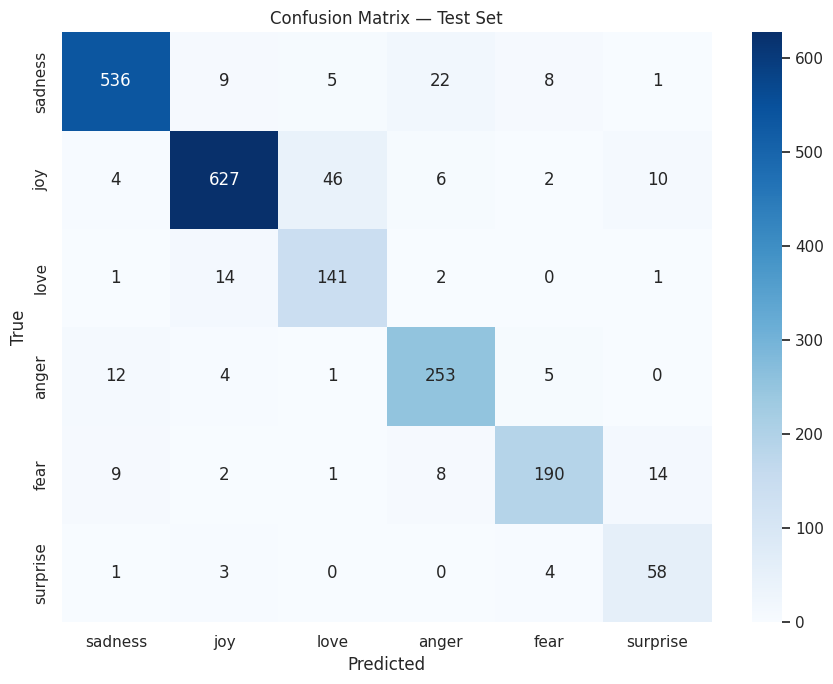

In [12]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax,
)
ax.set_title("Confusion Matrix — Test Set")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", bbox_inches="tight", dpi=150)
plt.show()

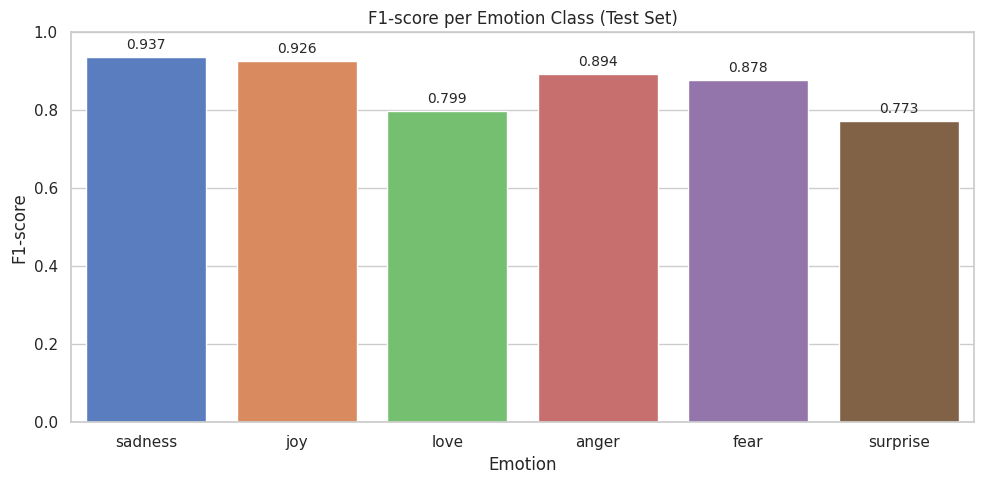

In [13]:
# Per-class F1 bar chart
per_class_f1 = f1_score(y_test, y_pred, average=None, zero_division=0)
f1_df = pd.DataFrame({"Emotion": LABEL_NAMES, "F1-score": per_class_f1})

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=f1_df, x="Emotion", y="F1-score", hue="Emotion", legend=False, ax=ax)
ax.set_title("F1-score per Emotion Class (Test Set)")
ax.set_ylim(0, 1)
for i, v in enumerate(per_class_f1):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "f1_per_class.png", bbox_inches="tight")
plt.show()

In [14]:
# Qualitative examples: correct vs misclassified
results_df = test_df[["text", "emotion"]].copy()
results_df["predicted"] = [LABEL_NAMES[i] for i in y_pred]
results_df["correct"] = results_df["emotion"] == results_df["predicted"]

print("Correct predictions (sample):")
display(results_df[results_df["correct"]].head(5))

print("\nMisclassified (sample):")
display(results_df[~results_df["correct"]].head(5))

Correct predictions (sample):


,text,emotion,predicted,correct
0,im feeling rather rotten so im not very ambiti...,sadness,sadness,True
1,im updating my blog because i feel shitty,sadness,sadness,True
2,i never make her separate from me because i do...,sadness,sadness,True
3,i left with my bouquet of red and yellow tulip...,joy,joy,True
4,i was feeling a little vain when i did this one,sadness,sadness,True



Misclassified (sample):


,text,emotion,predicted,correct
10,i don t feel particularly agitated,fear,anger,False
13,i just feel extremely comfortable with the gro...,joy,anger,False
20,im not sure the feeling of loss will ever go a...,sadness,love,False
36,i feel very honoured to be included in a magzi...,joy,surprise,False
49,i was feeling pretty anxious all day but my fi...,fear,joy,False


---
## 10. Conclusion & Future Work

### Summary

We built an end-to-end pipeline for **emotion detection in tweets** using the dair-ai Emotion dataset. After text cleaning and TF-IDF vectorization, a tuned **Logistic Regression** classifier achieved competitive results on the test set across all six emotion classes.

### Key Findings

- The dataset is **imbalanced** (sadness and joy dominate), which affects minority classes like surprise.
- Emotionally similar classes (e.g., **joy** vs **love**) are more frequently confused.
- TF-IDF + Logistic Regression provides a fast, interpretable baseline suitable for large-scale tweet streams.

### Future Work

1. Fine-tune a **transformer** model (e.g., DistilBERT) for higher accuracy
2. Apply **data augmentation** or oversampling for minority classes
3. Deploy as a REST API for real-time inference
4. Evaluate on more recent Twitter/X data to test generalization

### References (APA 7th)

- Saravia, E., Liu, H.-C., Huang, Y.-H., Wu, J., & Chen, Y.-S. (2018). CARER: Contextualized affect representations for emotion recognition. In *Proceedings of the 2018 Conference on Empirical Methods in Natural Language Processing* (pp. 3687–3697). https://doi.org/10.18653/v1/D18-1404
- dair-ai. (2020). *Emotion dataset* [Data set]. Hugging Face. https://huggingface.co/datasets/dair-ai/emotion
- Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, *12*, 2825–2830.